## **The purpose of this notebook is to visualize the alteration of clinical scale scores.**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_context("talk")
import matplotlib.pyplot as plt
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
from scipy.stats import ttest_rel,wilcoxon
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="Random effects covariance is singular")
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
### load clinical scales

# Match subjects at a given timepoint from the scale DataFrame
def fun_match_scale(scale,timepoint):
    result = pd.DataFrame([])
    df = scale.copy()
    process = df[df['condition'] == timepoint]
    for sub in sub_ls:
        if(sub in process.index):
            result = pd.concat([result,process.loc[sub,:]],axis=1)
    return result.T

madrs = pd.read_csv('/data/dy/TIS_MDD/Scales/madrs.csv') ## MADRS_all
madrs.index = madrs['sub']
hama = pd.read_csv('/data/dy/TIS_MDD/Scales/hama.csv') ## HAMA_all
hama.index = hama['sub']
hamd = pd.read_csv('/data/dy/TIS_MDD/Scales/hamd.csv') ## HAMD_all
hamd.index = hamd['sub']
psqi = pd.read_csv('/data/dy/TIS_MDD/Scales/psqi.csv') ## PSQI_ALL
psqi.index = psqi['sub']
qids = pd.read_csv('/data/dy/TIS_MDD/Scales/qids.csv') ## QIDS_all
qids.index = qids['sub']


In [4]:
responder = pd.read_csv(f"/data/dy/TIS_MDD/responder.csv", index_col = 0)

## Subject sub-010 was excluded due to an average head motion exceeding 0.5 mm.
responder = responder.drop("sub-010",axis = 0)
sub_ls = responder.index.tolist()
responder_proportion = responder[responder['responder'] == 'responder'].shape[0]/responder.shape[0]
print(f"Among all {len(sub_ls)} participants, responders accounted for {responder_proportion:.2%}.")

Among all 26 participants, responders accounted for 53.85%.


In [5]:
from scipy.stats import shapiro

# The normality of the scale was assessed using the Shapiro-Wilk test."
stat, p = shapiro(madrs[madrs['sub'].isin(responder.index)]["MADRS_all"])
print(f"MADRS p-value = {p:.4f}")
stat, p = shapiro(hamd[hamd['sub'].isin(responder.index)]["HAMD_all"])
print(f"HAMD p-value = {p:.4f}")
stat, p = shapiro(qids[qids['sub'].isin(responder.index)]["QIDS_all"])
print(f"QIDS p-value = {p:.4f}")
stat, p = shapiro(hama[hama['sub'].isin(responder.index)]["HAMA_all"])
print(f"HAMA p-value = {p:.4f}")
stat, p = shapiro(psqi[psqi['sub'].isin(responder.index)]["PSQI_ALL"])
print(f"PSQI p-value = {p:.4f}")

MADRS p-value = 0.0090
HAMD p-value = 0.0152
QIDS p-value = 0.0139
HAMA p-value = 0.0002
PSQI p-value = 0.3564


In [6]:
## Function for scale plotting

import ptitprince as pt
import statsmodels.formula.api as smf

# Convert p-value to significance stars (n.s., *, **, ***)
def p_star(p):
    if(p>0.05):
        return 'n.s.'
    elif(p>0.01):
        return '*'
    elif(p>0.001):
        return '**'
    else:
        return '***'

# Plot longitudinal RainCloud with paired subject lines and paired t-test significance bars
def longitudinal_plot_wise(df,value_col,time_order,
                      subj_col = 'sub',time_col='condition',figsize = (12,8),p_values = [],title=None,
                      value_label=None,display_labels=None,palette=None,regress=False,regress_col=None):
    # Set defaults for display labels, value label, palette, and regressors if not provided
    if(display_labels==None):
        display_labels = time_order
    if(value_label==None):
        value_label = value_col
    if(palette == None):
        palette = sns.color_palette("husl", len(time_order))
    if(regress and regress_col==None):
        regress_col = ['age','sex_id']
    
    # Create figure and draw RainCloud (half-violin + box + scatter)
    fig, ax = plt.subplots(figsize=figsize,dpi=300)
    
    pt.RainCloud(x=time_col, y=value_col, data=df, order=time_order, palette=palette,
                     bw=.2, width_viol=1, width_box=.4, offset=.25,alpha=.75, move=-0.0, ax=ax, orient='v',point_size=12)
    
    # Adjust y/x limits to leave room for significance brackets above
    y_max = df[value_col].max()
    y_min = df[value_col].min()
    data_range = y_max - y_min
    step = data_range*.15
    ax.set_ylim(y_min - data_range*0.05,
                y_max + data_range*0.1 + len(time_order)*step)
    ax.set_xlim(-.8,len(time_order)-.6)
    
    # Set axis labels and tick labels
    ax.set_xlabel('')
    ax.set_xticklabels(display_labels, fontsize=18)
    ax.set_xticks(range(len(time_order)))
    ax.set_ylabel(value_label,labelpad=10, fontsize=20)
    if(title!=None):
        ax.set_title(title,fontsize=20)

    # Draw horizontal significance bars and star annotations between adjacent time points
    h = data_range * 0.04
    current_y = y_max + data_range*0.05
    
    # Compare time_order[0] vs time_order[1] with paired t-test
    a = df[df['condition']==time_order[0]];a.index=a['sub']
    b = df[df['condition']==time_order[1]];b.index=b['sub']
    valid_index = pd.concat([a,b],axis=1).dropna(axis=0).index.tolist()
    _,p =  ttest_rel(a.loc[valid_index,value_col],b.loc[valid_index,value_col])
    plt.plot([0,0,1,1],[current_y,current_y+h,current_y+h,current_y],lw=2, c='k')
    plt.text(1/2, current_y+h, p_star(p), ha='center', va='bottom', fontsize=15)
    
    # If there are 3 time points, draw two more comparisons: 1vs2 and 0vs2
    if(len(time_order)==3):
        current_y+= step
        a = df[df['condition']==time_order[1]];a.index=a['sub']
        b = df[df['condition']==time_order[2]];b.index=b['sub']
        valid_index = pd.concat([a,b],axis=1).dropna(axis=0).index.tolist()
        _,p =  ttest_rel(a.loc[valid_index,value_col],b.loc[valid_index,value_col])
        plt.plot([1,1,2,2],[current_y,current_y+h,current_y+h,current_y],lw=2, c='k')
        plt.text(3/2, current_y+h, p_star(p), ha='center', va='bottom', fontsize=15)
        current_y+= step
        a = df[df['condition']==time_order[0]];a.index=a['sub']
        b = df[df['condition']==time_order[2]];b.index=b['sub']
        valid_index = pd.concat([a,b],axis=1).dropna(axis=0).index.tolist()
        _,p =  ttest_rel(a.loc[valid_index,value_col],b.loc[valid_index,value_col])
        plt.plot([0,0,2,2],[current_y,current_y+h,current_y+h,current_y],lw=2, c='k')
        plt.text(1, current_y+h, p_star(p), ha='center', va='bottom', fontsize=15)
    
    # Draw individual subject trajectories as semi-transparent gray lines
    x_pos = {t:i for i,t in enumerate(time_order)}
    for sid, g in df.groupby(subj_col):
        g = g.dropna(subset=[value_col]).sort_values(time_col)
        if g[time_col].nunique() >= 2:
            xs = [x_pos[t] for t in g[time_col]]
            ys = g[value_col].to_list()
            ax.plot(xs, ys, color='0.78', alpha=0.55, linewidth=2)

# Reshape raw scale data into long format (rows = subject × timepoint)
def find_all_scale(scale,col_name,times=['pre','5th','4week']):
    result = pd.DataFrame([])
    for time in times:
        a = pd.DataFrame(fun_match_scale(scale,time)[col_name])
        a['time'] = [time for _ in range(a.shape[0])]
        result = pd.concat([result,a])
    result['sub'] = result.index
    return result

scale_dict = {"MADRS_all":madrs,"HAMD_all":hamd,"QIDS_all":qids,"HAMA_all":hama,"PSQI_ALL":psqi}


MADRS_all F=103.386 p=0.000
HAMD_all F=118.062 p=0.000
QIDS_all F=65.666 p=0.000
HAMA_all F=87.088 p=0.000


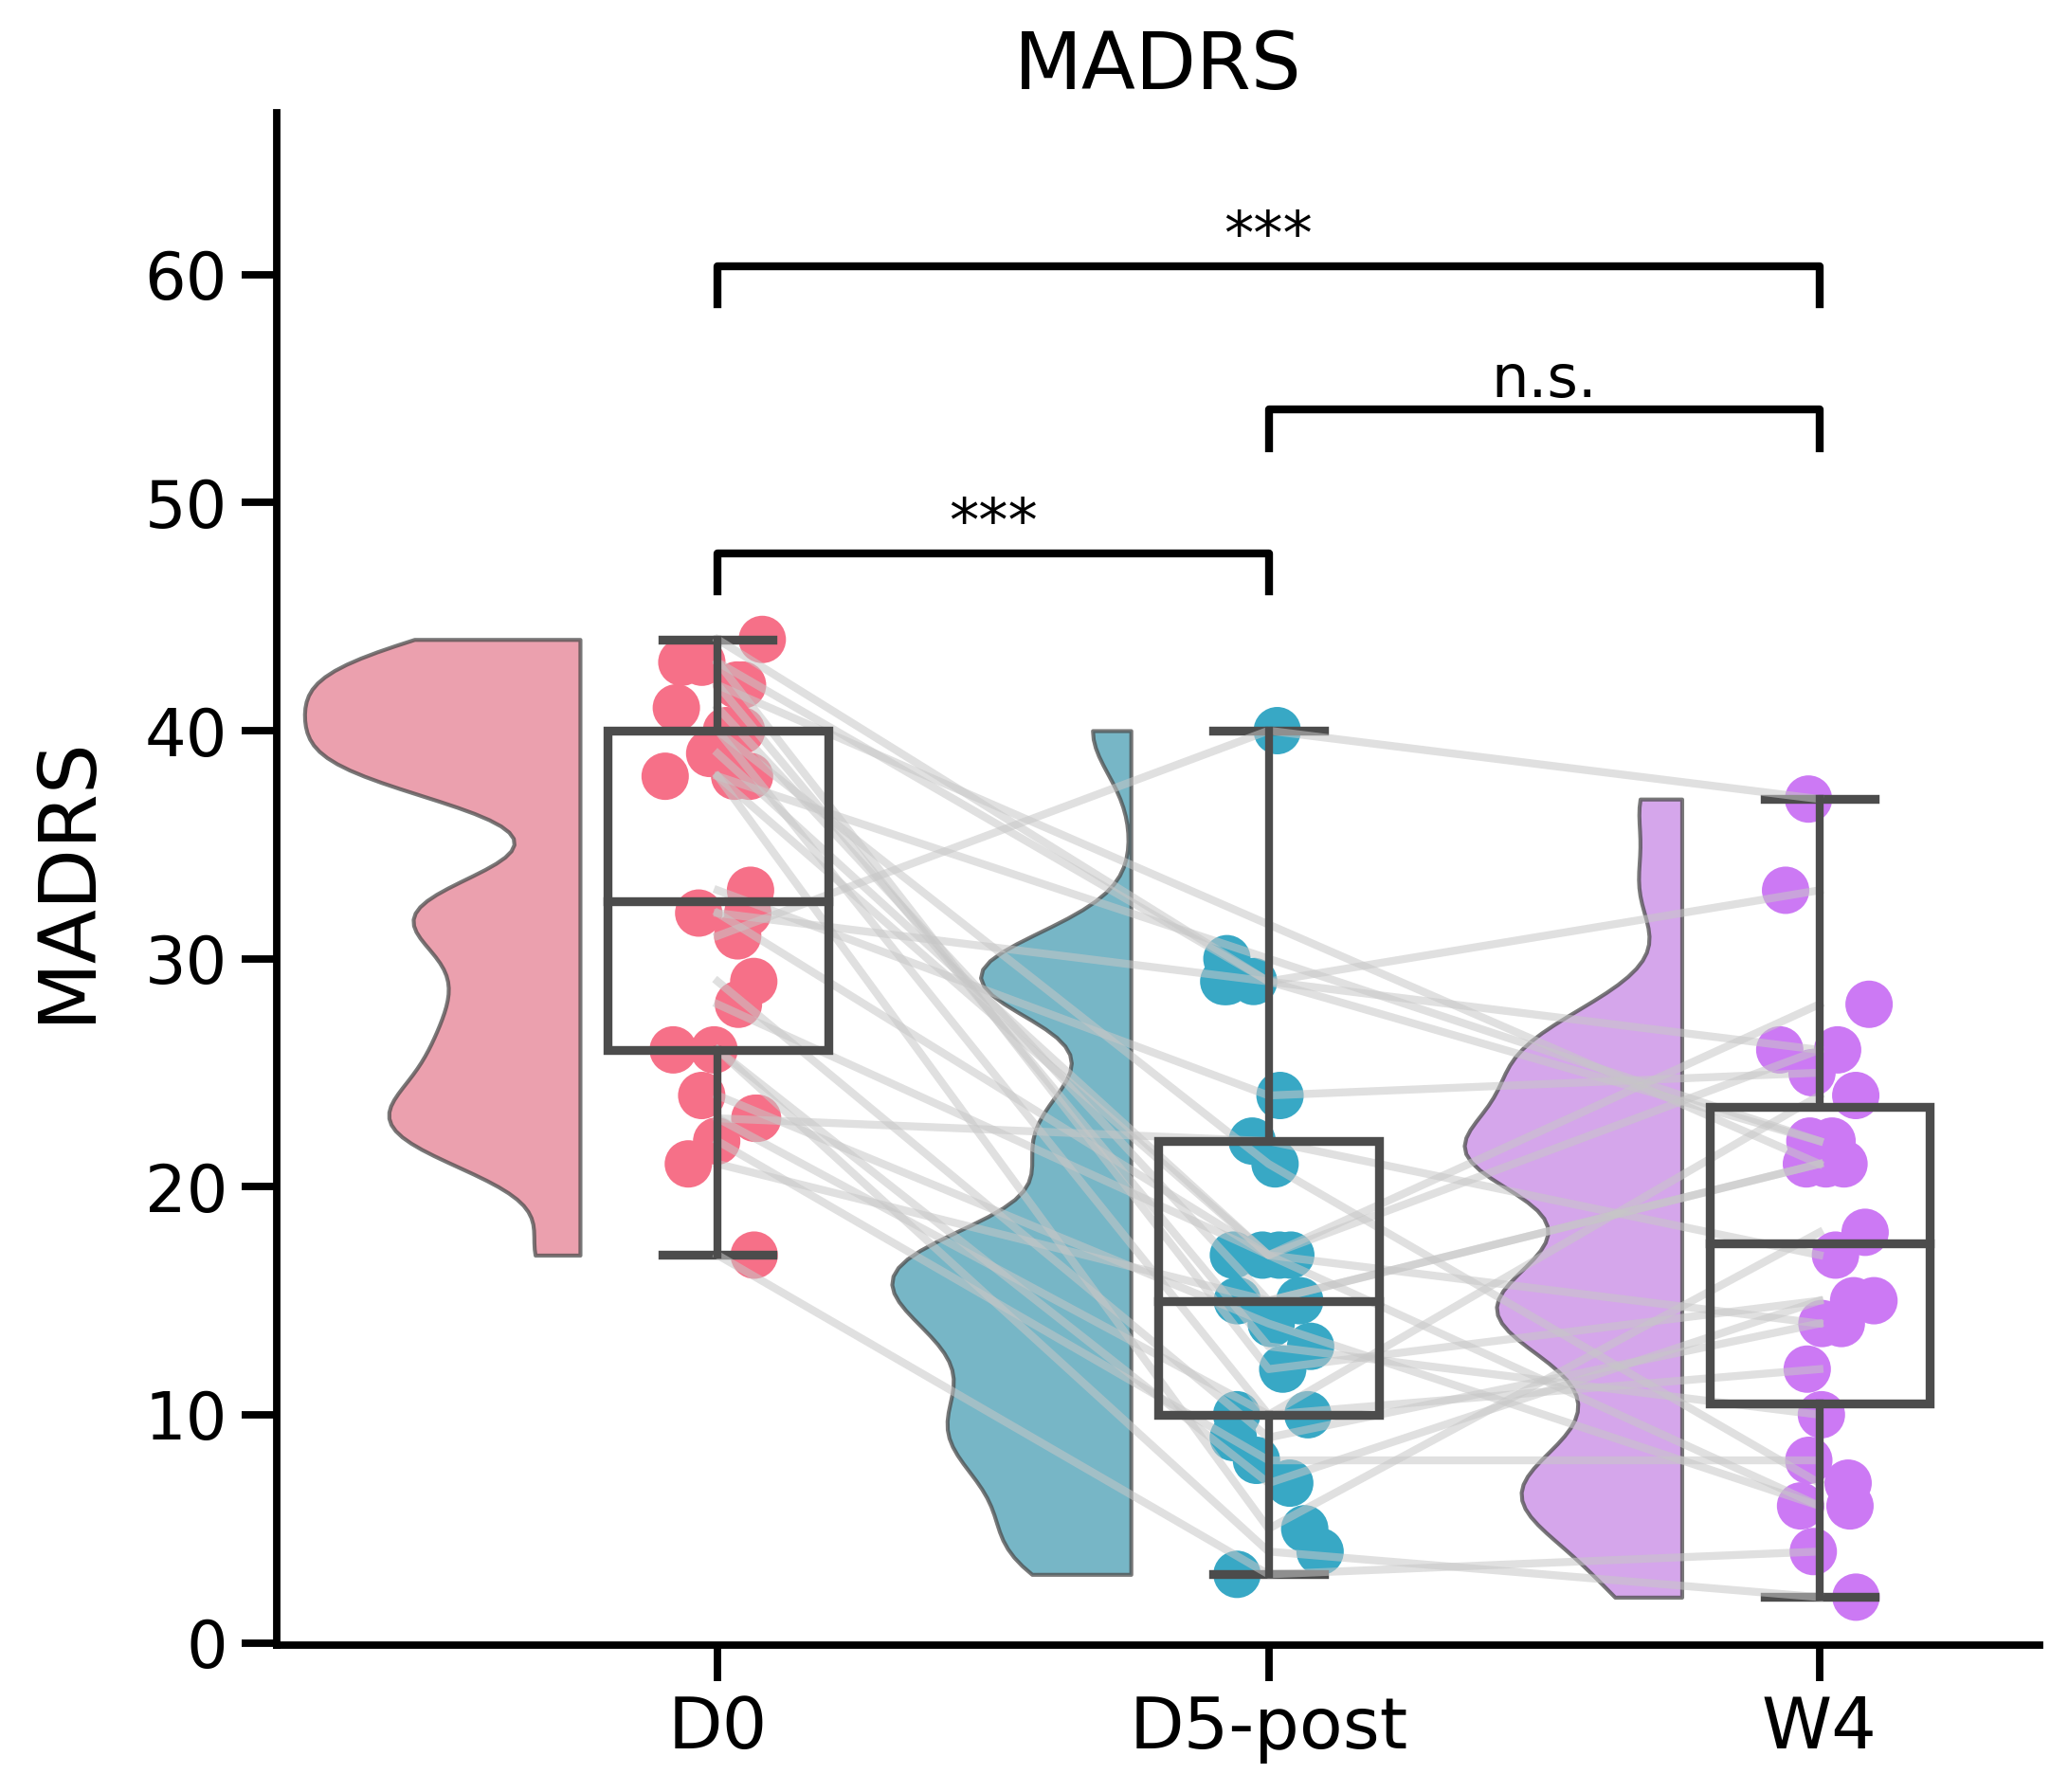

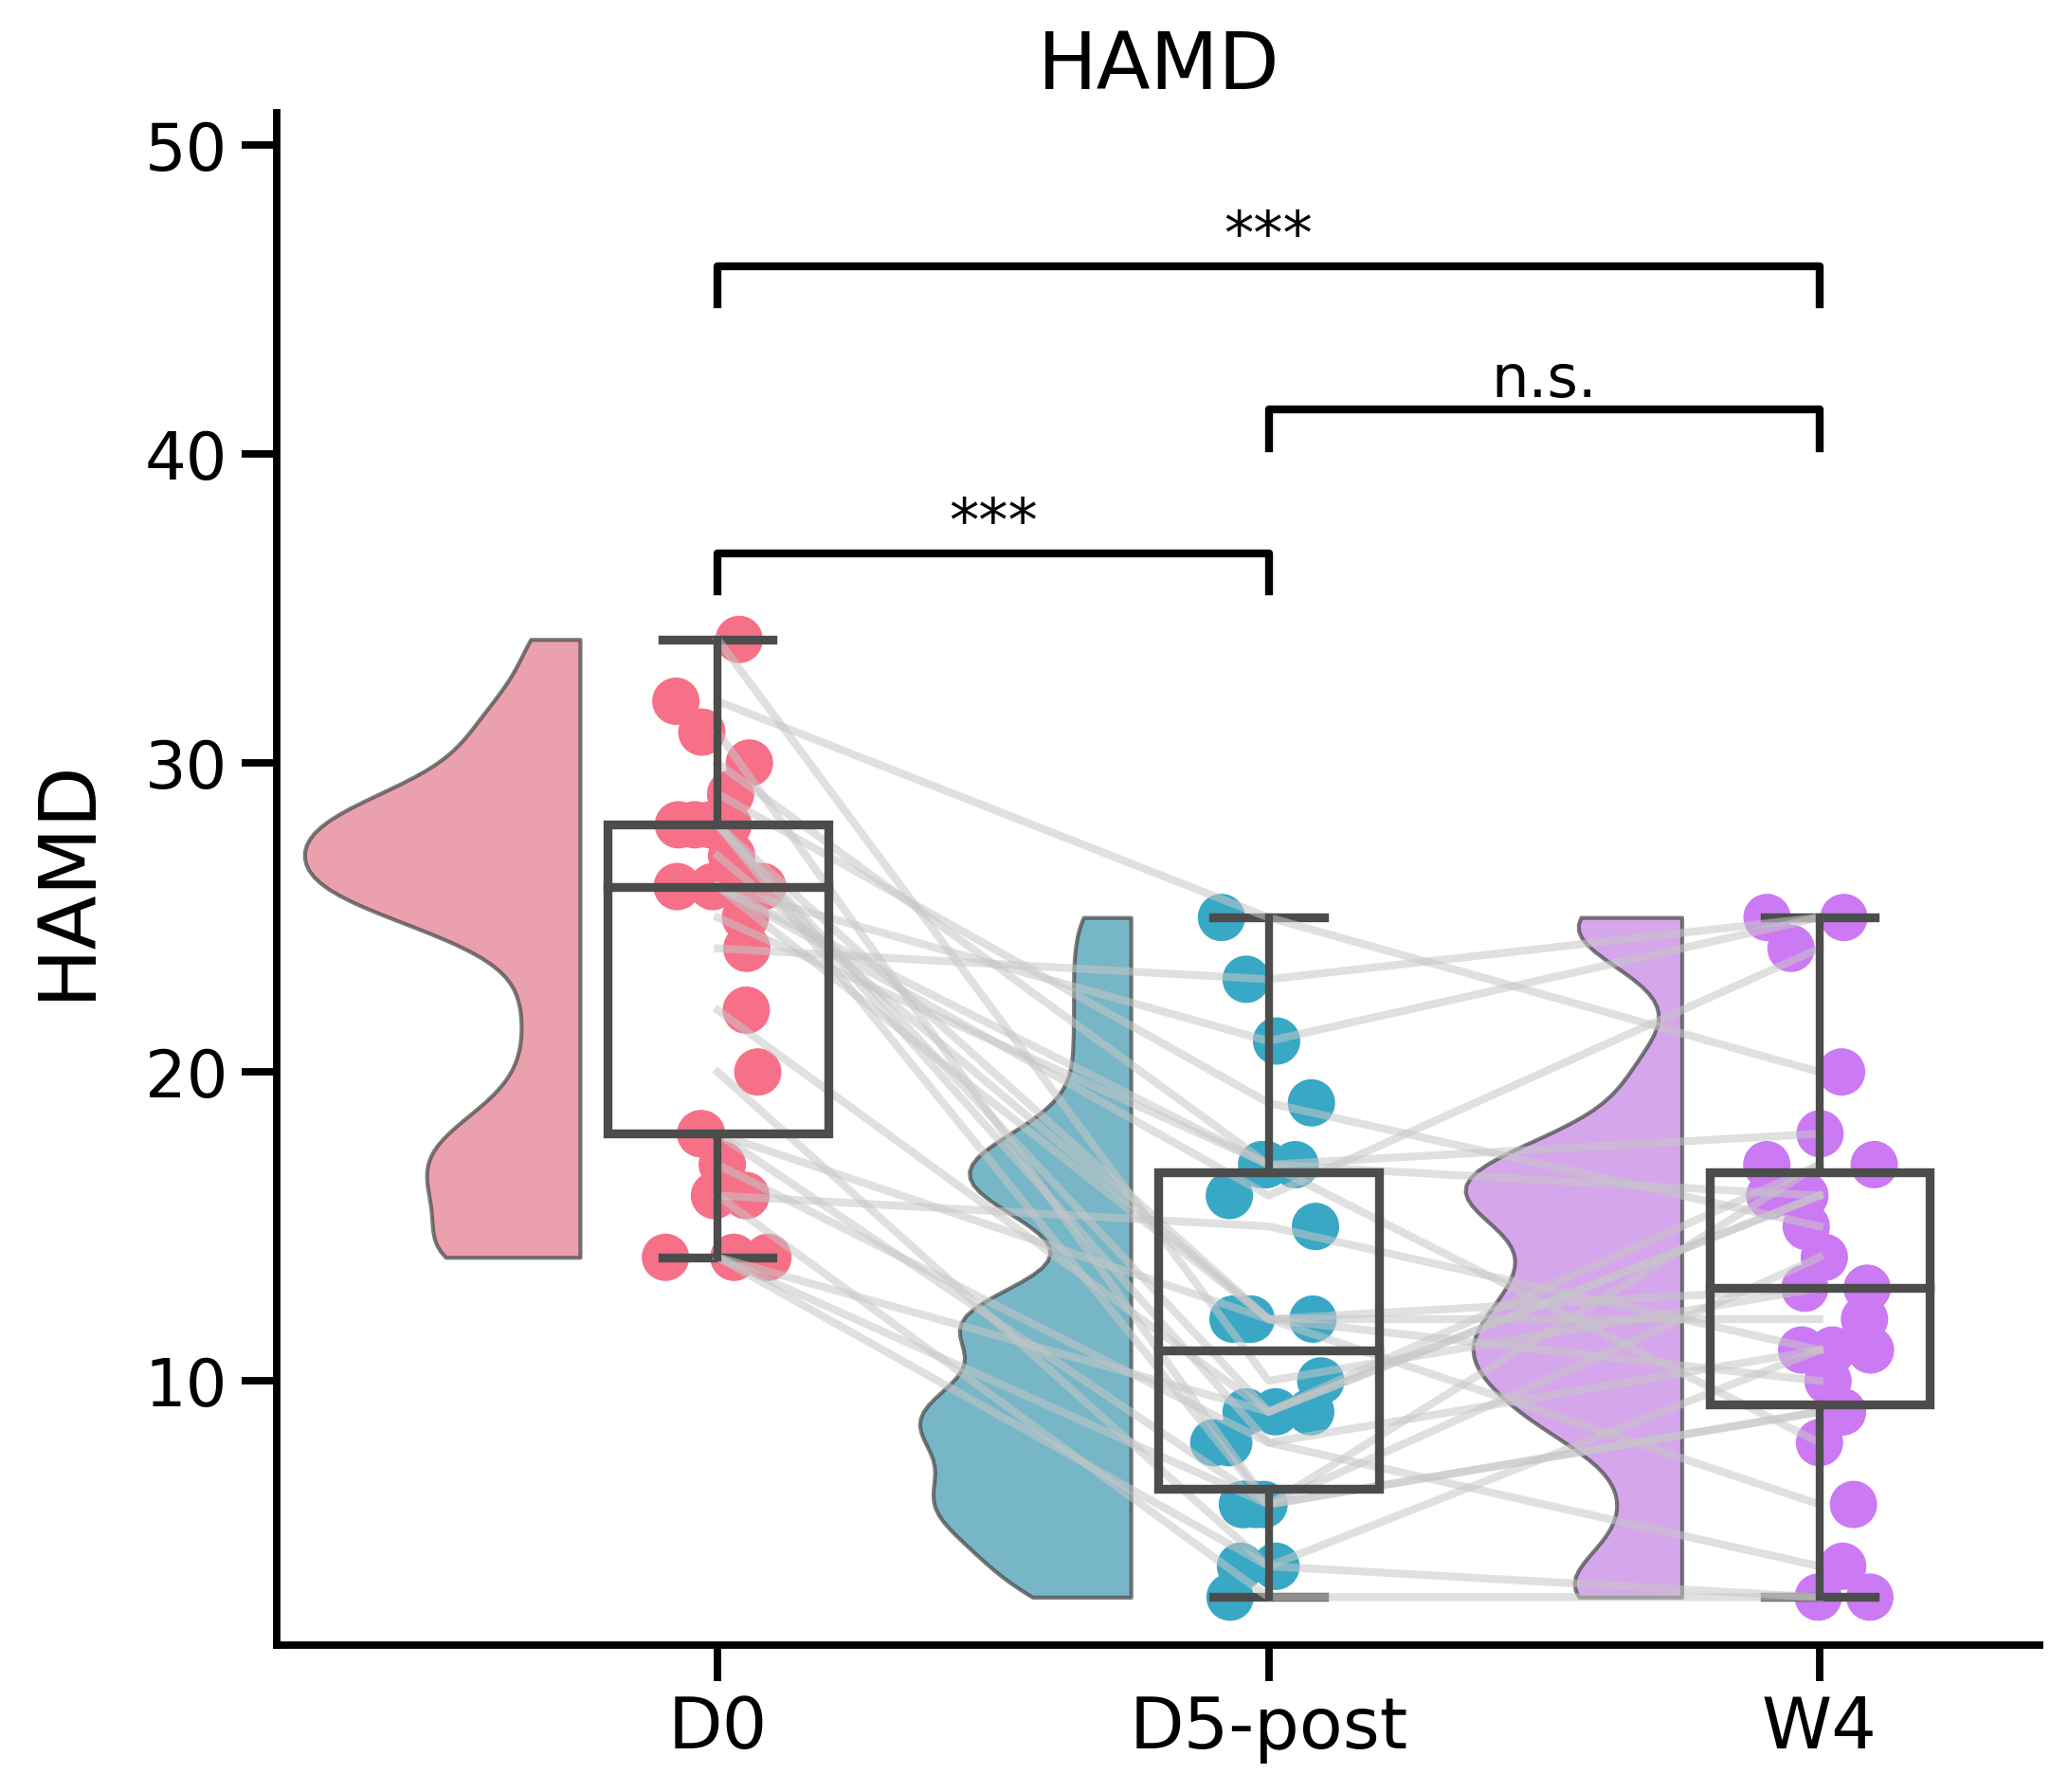

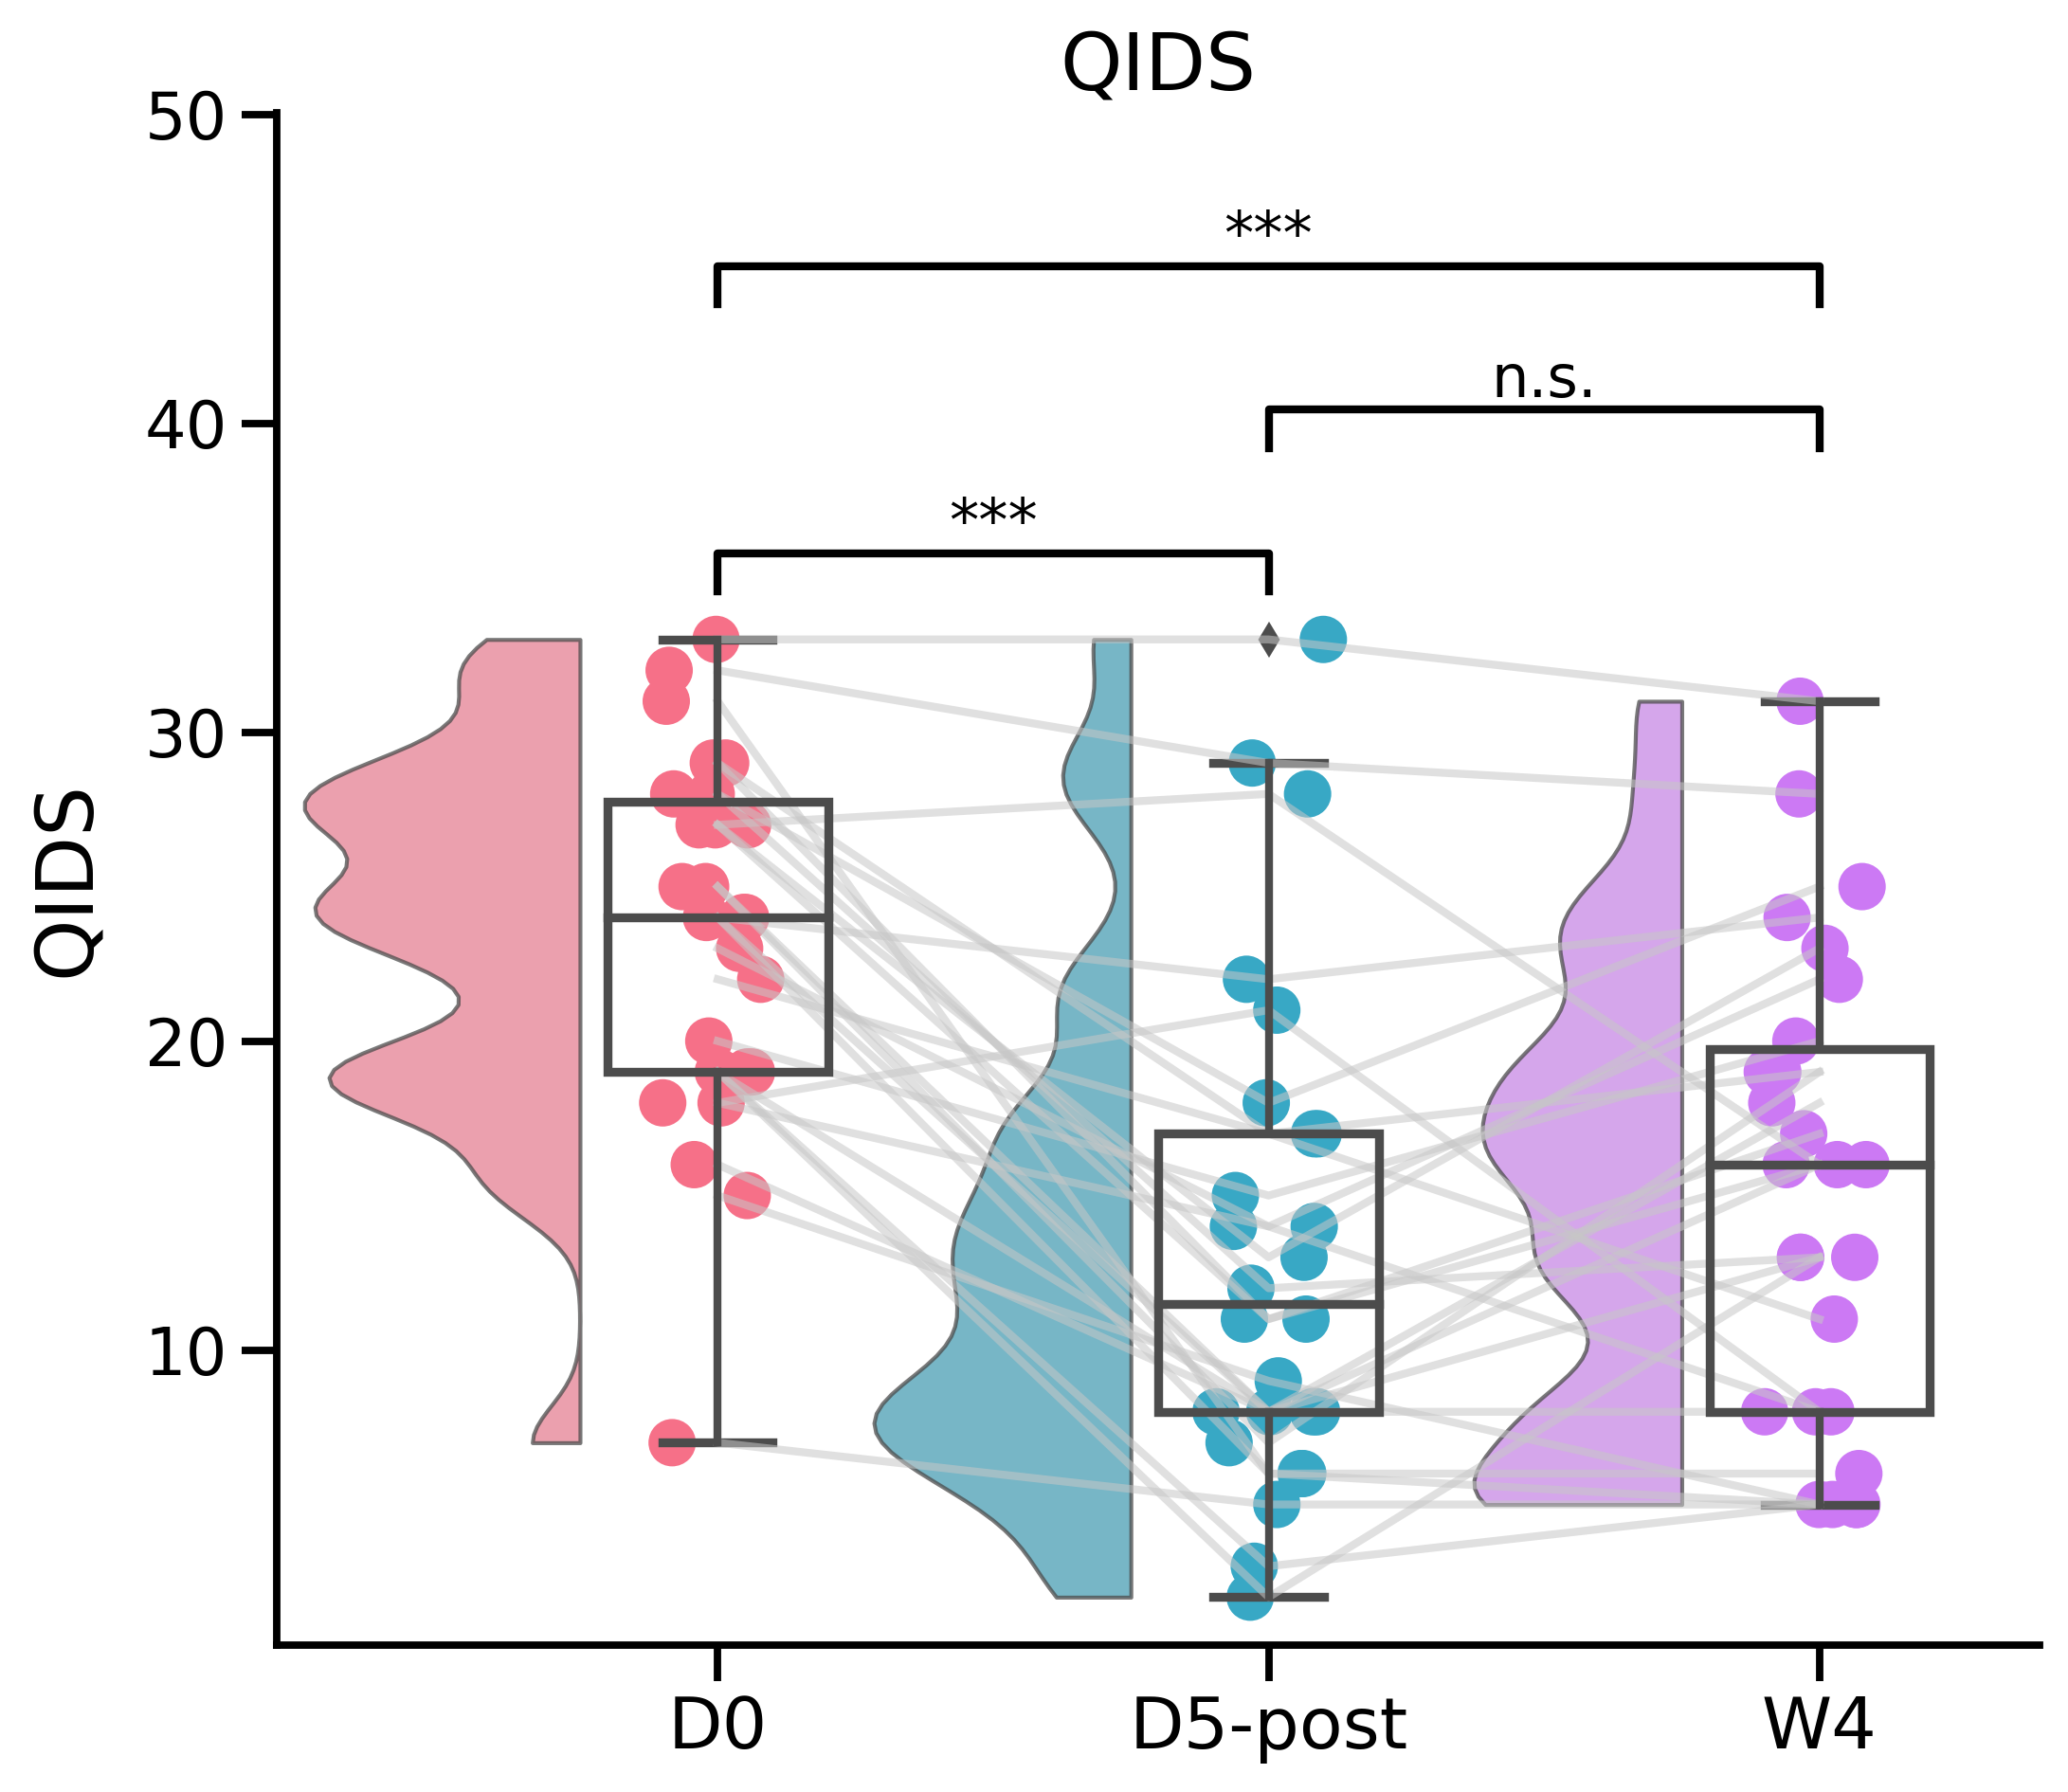

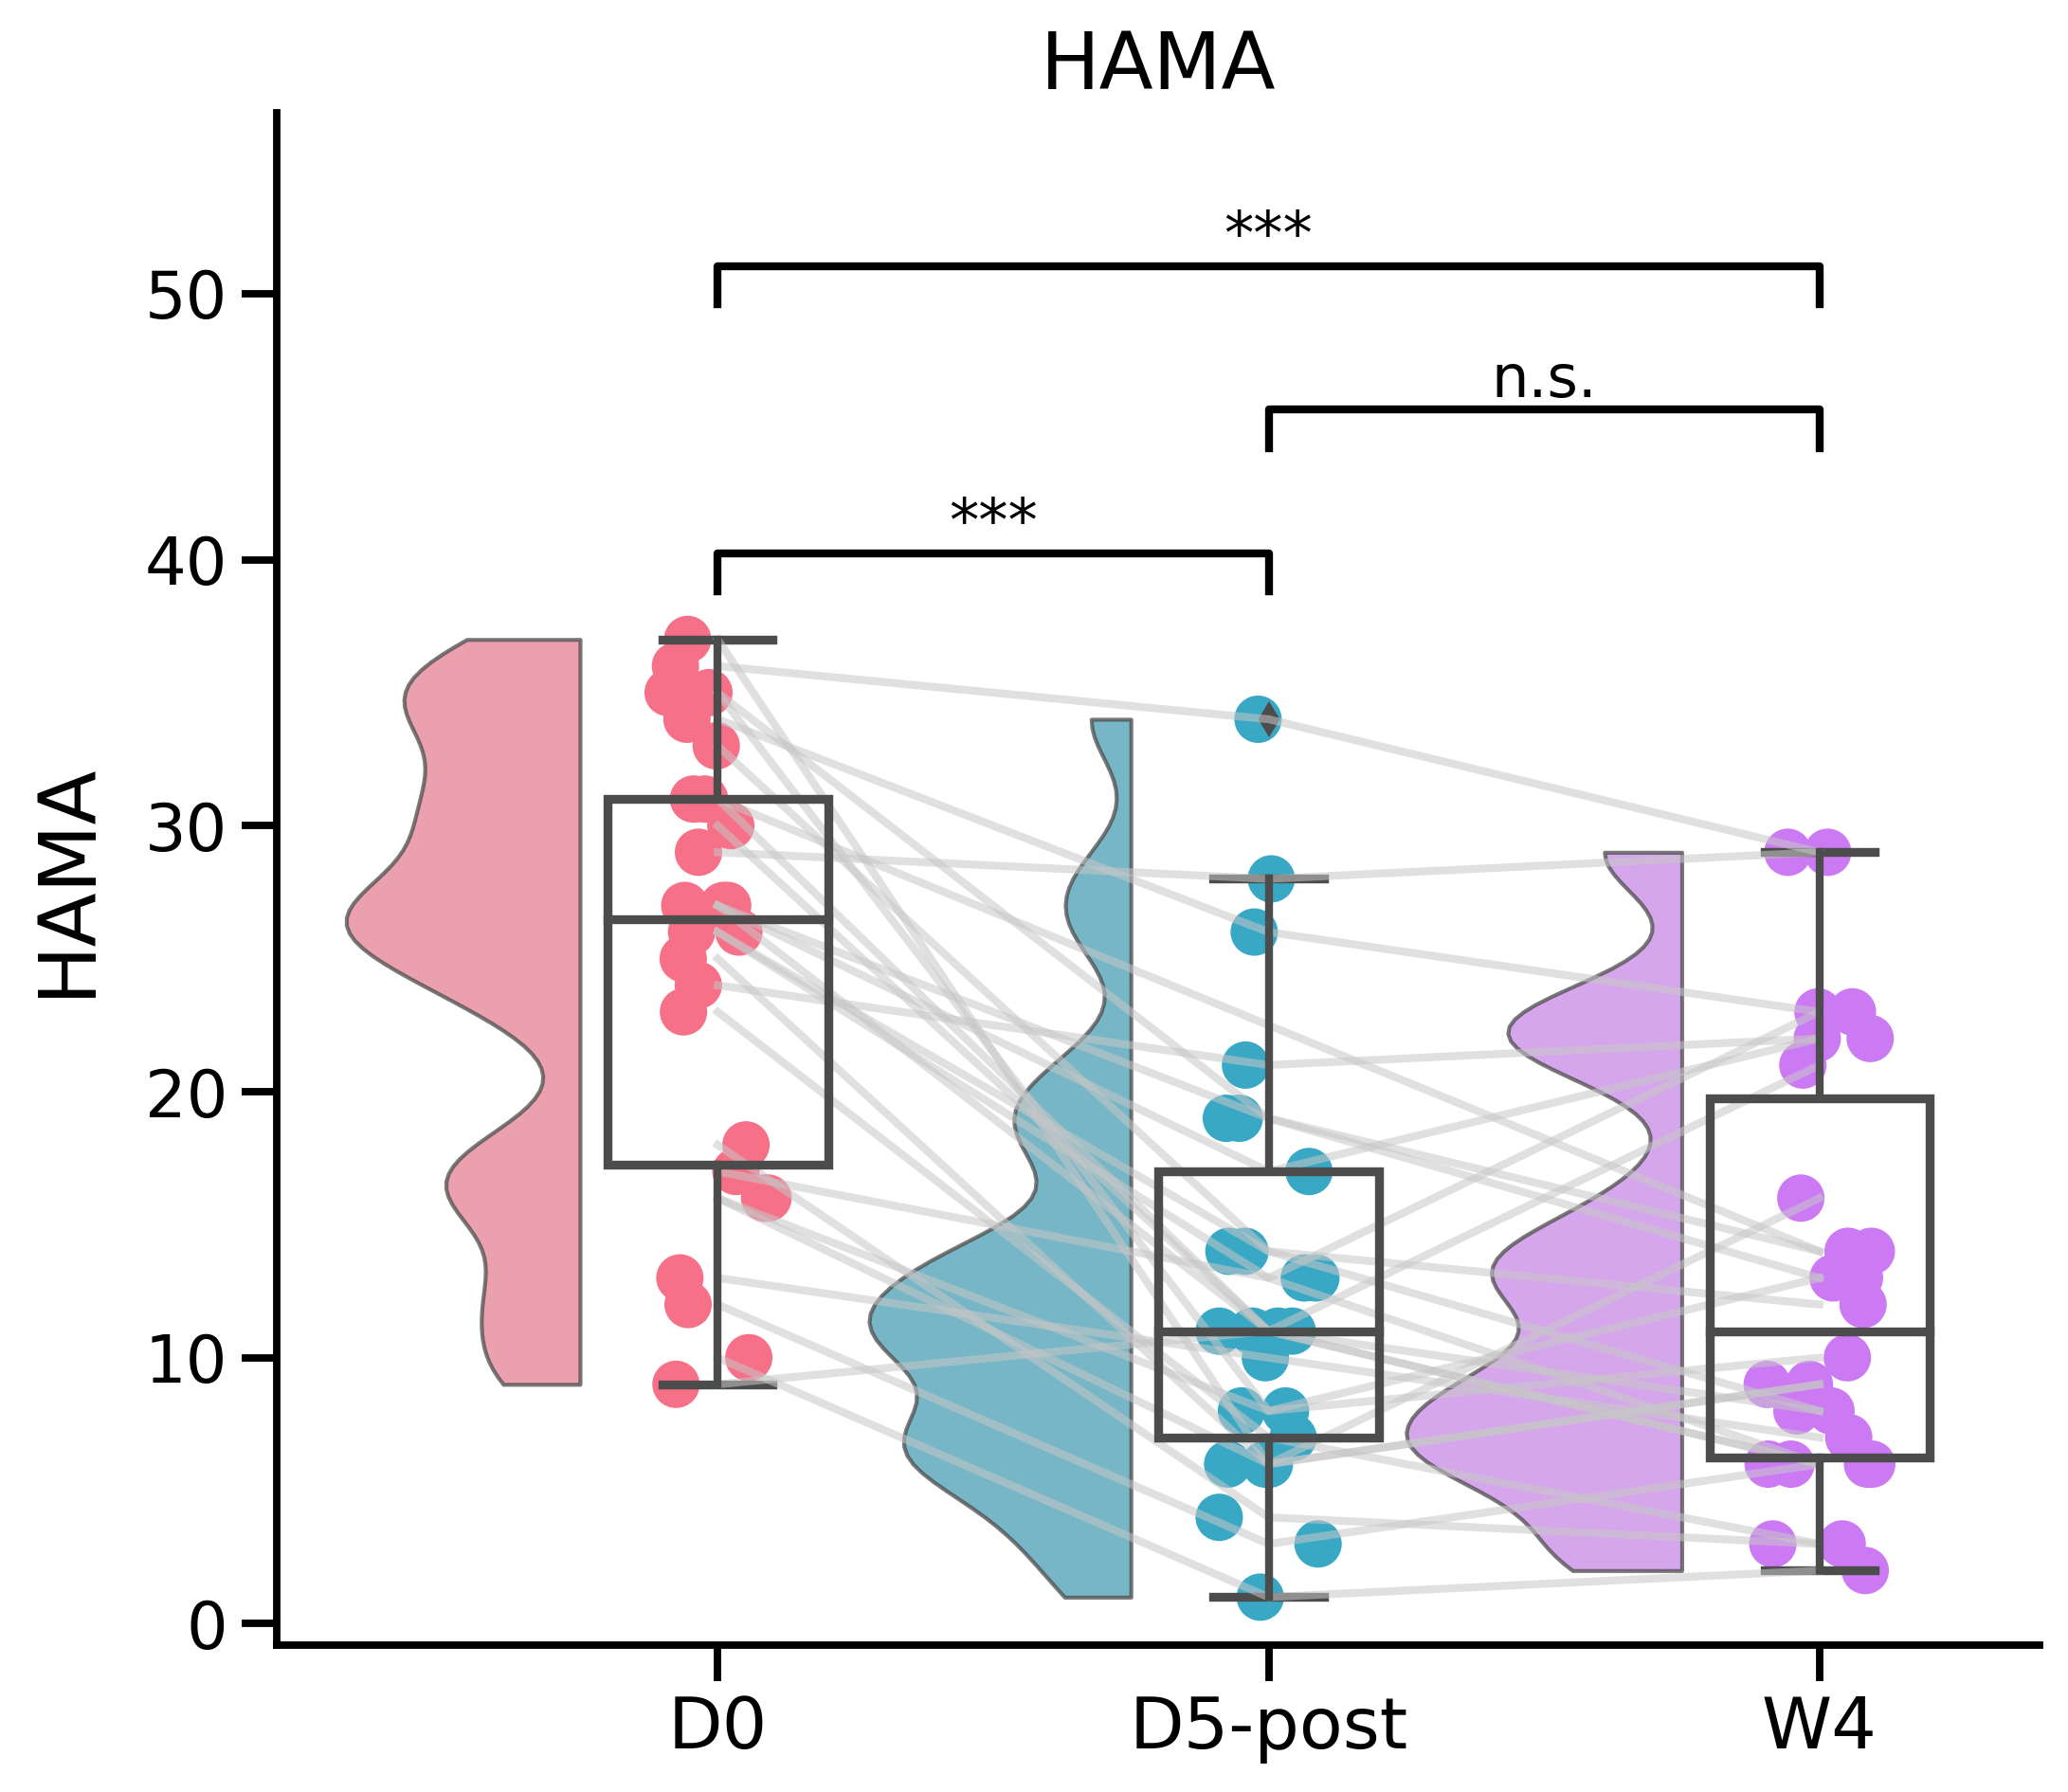

In [7]:
# Loop over four clinical scales to fit mixed-effects models and save RainCloud plots
for col_name in ['MADRS_all','HAMD_all','QIDS_all','HAMA_all']:
    # Copy raw scale data and reshape into long format with condition & subject columns
    scale = scale_dict[col_name].copy()
    df = find_all_scale(scale,col_name)
    df.columns = [col_name,'condition','sub']
    df[col_name] = np.array(df[col_name]).astype(np.float64)

    # Fit a linear mixed-effects model: scale ~ condition, with subject as random intercept
    model = smf.mixedlm(f"{col_name} ~ condition", data = df, groups = df['sub']).fit()

    # Extract Wald F-statistic and its p-value for the condition effect
    F = model.wald_test_terms().summary_frame().iloc[-1,0][0][0]
    p_F = model.wald_test_terms().summary_frame().iloc[-1,1]
    print(f"{col_name} F={F:.3f} p={p_F:.3f}")

    # Define time points, display labels, and color palette for the longitudinal plot
    time_order=['pre','5th','4week']
    display_labels=['D0','D5-post','W4']
    palette=['#f67088','#38a8c5','#cc79f4']
    
    # Generate the RainCloud longitudinal plot with paired subject lines and significance bars
    longitudinal_plot_wise(df=df,value_col=col_name,time_order=time_order,
                           figsize = (8,7),p_values = [],title=col_name[:-4],
                          value_label=col_name[:-4],display_labels=display_labels,
                           palette=palette)

PSQI_ALL F=24.498 p=0.000


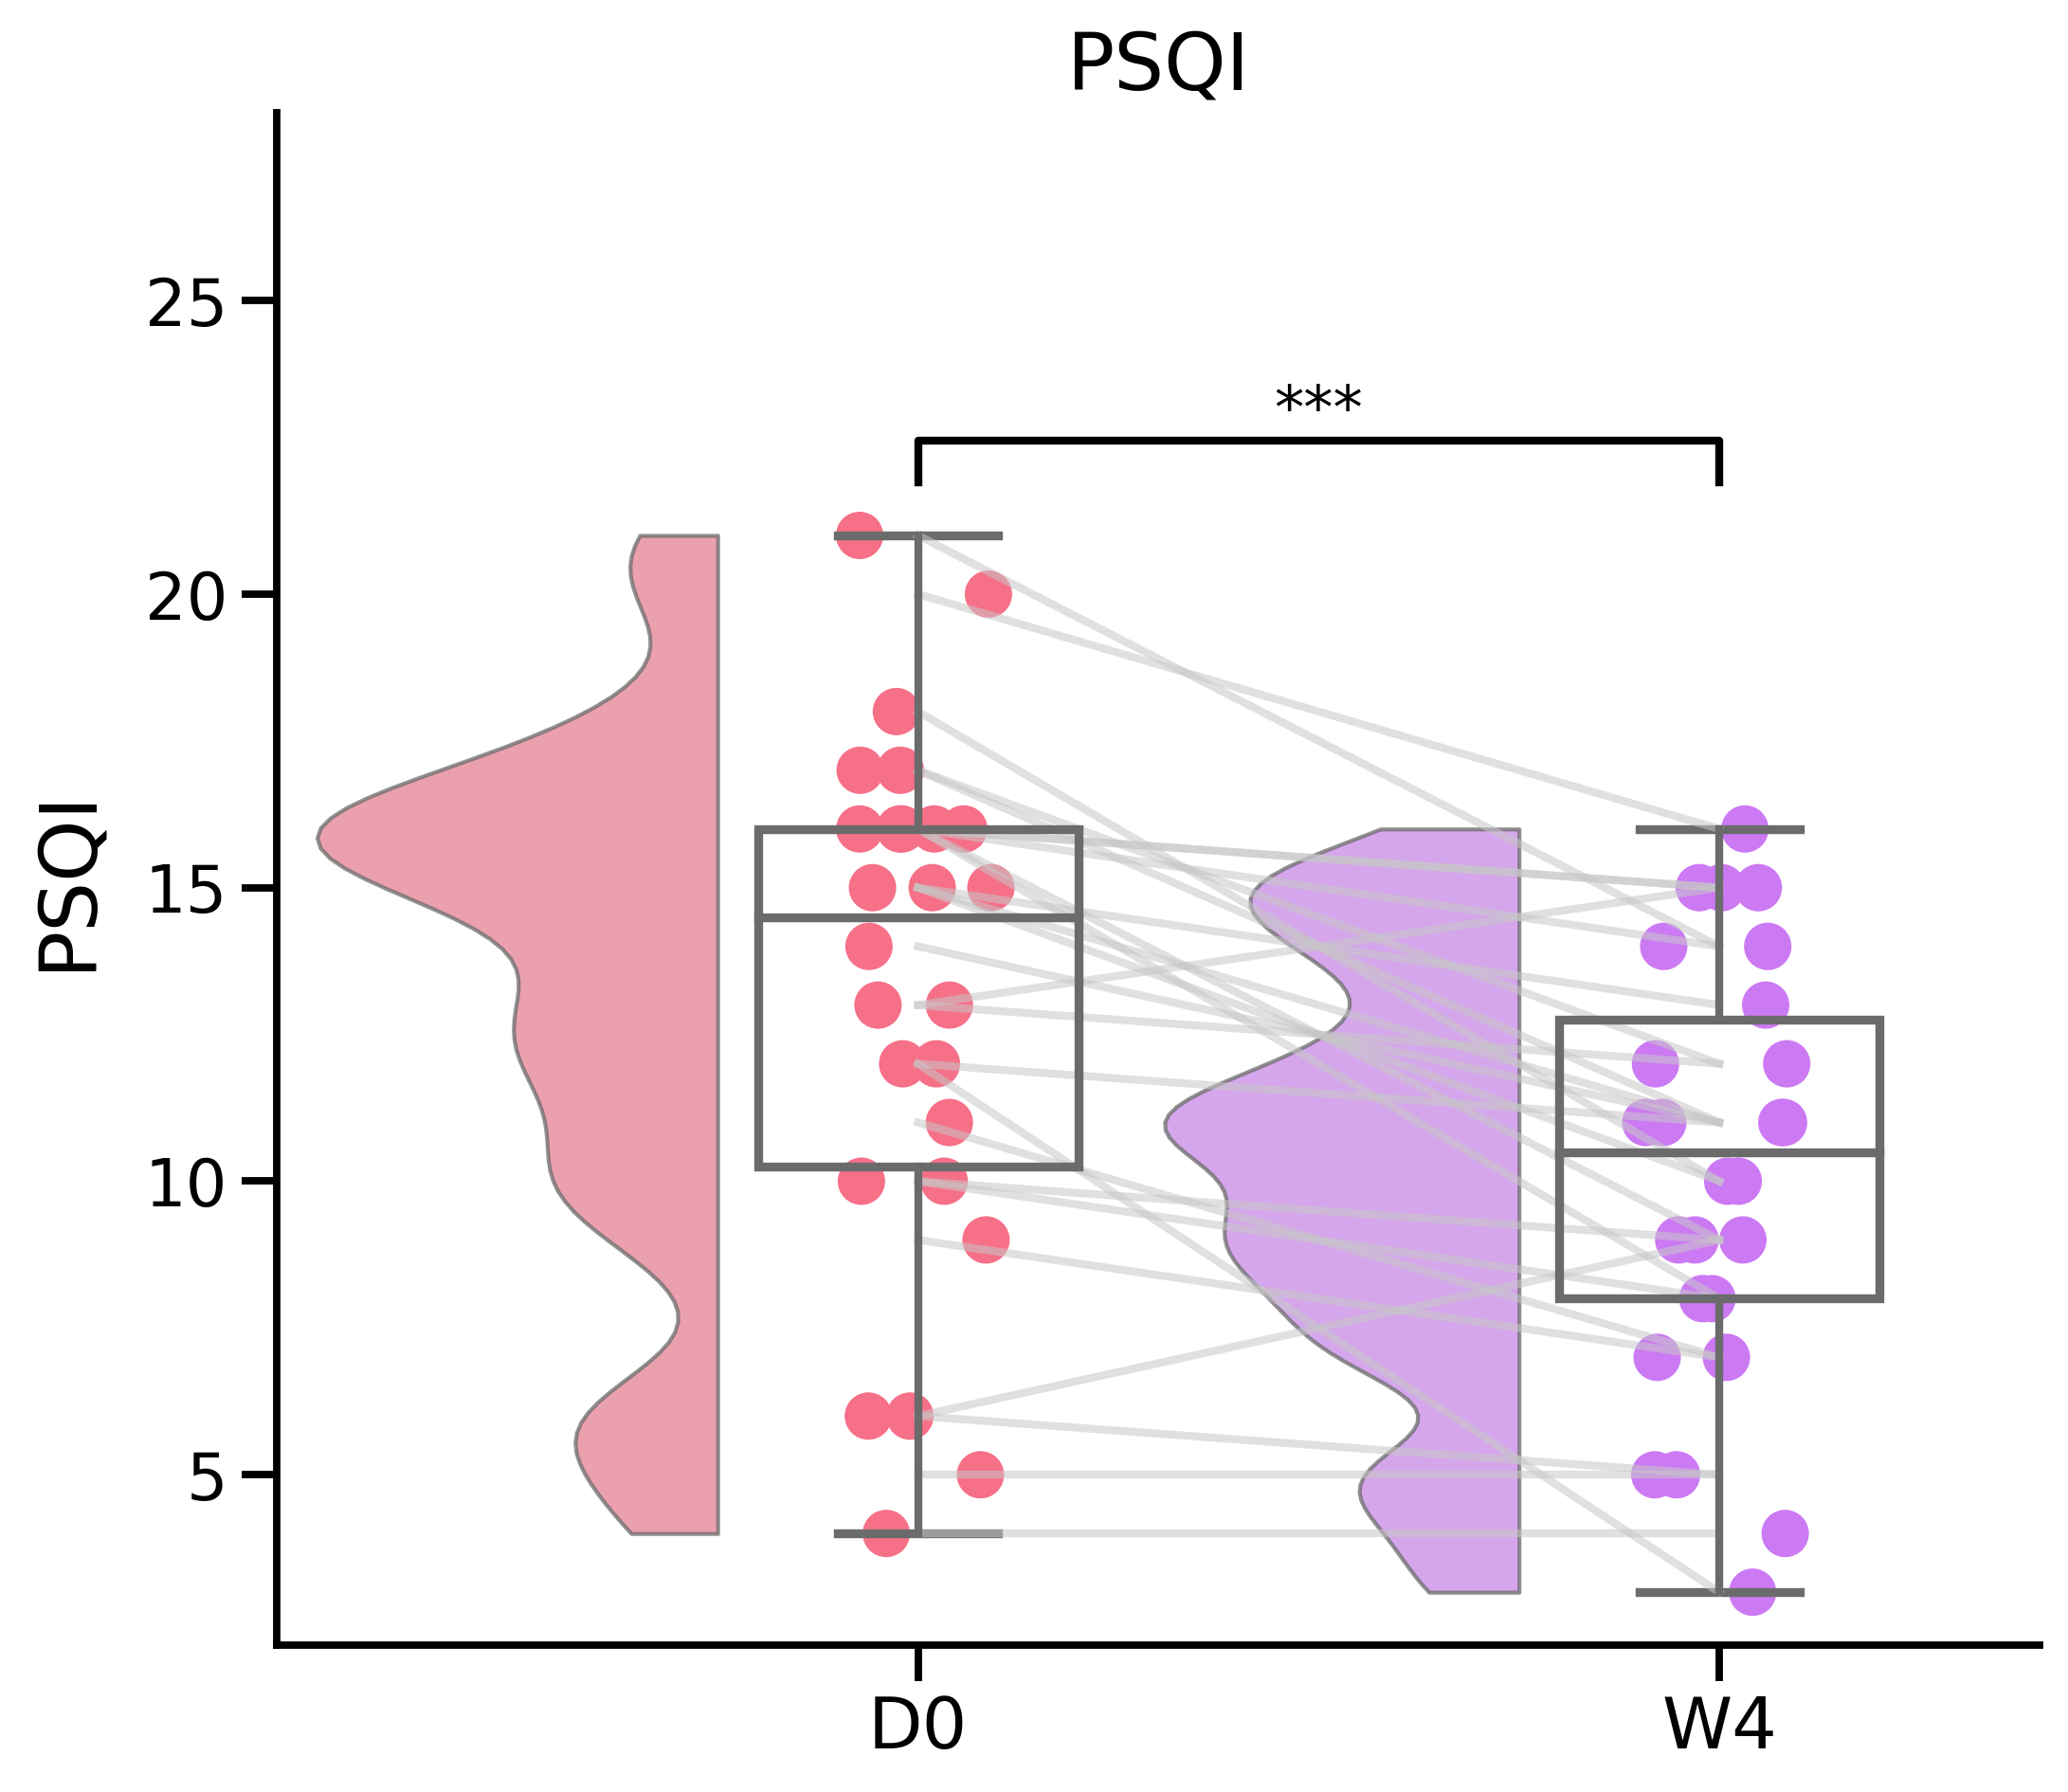

In [8]:
# PSQI has only two time points (pre, 4week), so handle it separately
col_name = 'PSQI_ALL'
time_order=['pre','4week']
# Reshape PSQI data into long format
df = find_all_scale(psqi,col_name,time_order)
df.columns = [col_name,'condition','sub']
df[col_name] = np.array(df[col_name]).astype(np.float64)

# Fit mixed-effects model for PSQI
model = smf.mixedlm(f"{col_name} ~ condition", data = df, groups = df['sub']).fit()
F = model.wald_test_terms().summary_frame().iloc[-1,0][0][0]
p_F = model.wald_test_terms().summary_frame().iloc[-1,1]
print(f"{col_name} F={F:.3f} p={p_F:.3f}")

# Longitudinal plot with two time points and two colors
display_labels=['D0','W4']
palette=['#f67088','#cc79f4']
longitudinal_plot_wise(df=df,value_col=col_name,time_order=time_order,
                       figsize = (8,7),p_values = [],title=col_name[:-4],
                      value_label=col_name[:-4],display_labels=display_labels,
                       palette=palette)
# Save data and figure
df.to_excel(f"~/2025/MDD-tTIS/Code/xlsx/01_{col_name}.xlsx",index=False)
